# 🔬 SAST Prototype — Stage 1: Tokenizer
**MTech Project | Static Analysis Security Tool**

This notebook covers **Stage 1** of the pipeline:

```
Java / Python File
        ↓
   Tokenizer       ← YOU ARE HERE
        ↓
     TF-IDF
        ↓
  Random Forest
        ↓
Safe / Vulnerable
```

The tokenizer converts raw code snippets into clean token strings ready for TF-IDF vectorisation.

# 🔬 SAST Prototype — Stage 1: Tokenizer
**MTech Project | Static Analysis Security Tool**

This notebook covers **Stage 1** of the pipeline:

```
Java / Python File
        ↓
   Tokenizer       ← YOU ARE HERE
        ↓
     TF-IDF
        ↓
  Random Forest
        ↓
Safe / Vulnerable
```

The tokenizer converts raw code snippets into clean token strings ready for TF-IDF vectorisation.

## 📦 1. Imports

In [1]:
import re
import pandas as pd

## 🔧 2. Tokenizer Functions

In [2]:
# This tokenizer converts raw source code (Java, Python, C++, etc.)
# into a clean sequence of meaningful words (tokens).
#
# The generated tokens can be used as input features for Machine Learning
# algorithms such as TF-IDF, Naive Bayes, Random Forest, or other NLP-based
# models for tasks like vulnerability detection, code classification,
# and code similarity analysis.

In [3]:
def _remove_block_comments(code: str) -> str:
    """Remove /* ... */ and /** ... */ blocks."""
    return re.sub(r"/\*.*?\*/", " ", code, flags=re.DOTALL)

def _remove_single_line_comments(code: str) -> str:
    """Remove // ... and # ... comments."""
    return re.sub(r"(//|#)[^\n]*", " ", code)

def _remove_string_literals(code: str) -> str:
    """Replace quoted strings with STRING_LITERAL placeholder.
    
    Keeping the placeholder preserves the signal that *something* was
    embedded — critical for detecting hardcoded secrets.
    """
    code = re.sub(r'"(?:[^"\\]|\\.)*"', " STRING_LITERAL ", code)
    code = re.sub(r"'(?:[^'\\]|\\.)*'", " STRING_LITERAL ", code)
    return code

def _split_camel_case(token: str) -> str:
    """getUserInput → get User Input (improves TF-IDF vocab for Java)."""
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", token)

def _tokenise(code: str) -> list:
    """Return lowercase alphanumeric tokens of length >= 2."""
    tokens = re.findall(r"[A-Za-z_][A-Za-z0-9_]*", code)
    expanded = []
    for tok in tokens:
        for sub in _split_camel_case(tok).split():
            sub = sub.lower()
            if len(sub) >= 2:
                expanded.append(sub)
    return expanded

def tokenize(code: str) -> str:
    """
    Full tokenisation pipeline.
    
    raw code → strip comments → replace strings → split tokens → join
    
    Returns space-joined token string ready for TF-IDF.
    """
    code = _remove_block_comments(code)
    code = _remove_single_line_comments(code)
    code = _remove_string_literals(code)
    return " ".join(_tokenise(code))

def tokenize_series(series):
    """Vectorised helper: applies tokenize() to a pandas Series."""
    return series.fillna("").apply(tokenize)

print("✅ Tokenizer functions defined.")

✅ Tokenizer functions defined.


## 🧪 3. Smoke Test — Single Snippets

In [4]:
samples = [
    {"label": "SQL Injection",
     "code":  'query = "SELECT * FROM users WHERE id = " + userId'},
    {"label": "Hardcoded Secret",
     "code":  'AWS_SECRET = "wJalrXUtnFEMI/K7MDENG/bPxRfiCYEXAMPLEKEY"'},
    {"label": "Insecure API",
     "code":  'requests.get(url, verify=False)'},
    {"label": "Safe",
     "code":  'cursor.execute("SELECT * FROM users WHERE id = %s", (uid,))'},
]

print("-" * 70)
for s in samples:
    tokens = tokenize(s["code"])
    print(f"Label  : {s['label']}")
    print(f"Input  : {s['code']}")
    print(f"Tokens : {tokens}")
    print("-" * 70)

----------------------------------------------------------------------
Label  : SQL Injection
Input  : query = "SELECT * FROM users WHERE id = " + userId
Tokens : query string_literal user id
----------------------------------------------------------------------
Label  : Hardcoded Secret
Input  : AWS_SECRET = "wJalrXUtnFEMI/K7MDENG/bPxRfiCYEXAMPLEKEY"
Tokens : aws_secret string_literal
----------------------------------------------------------------------
Label  : Insecure API
Input  : requests.get(url, verify=False)
Tokens : requests get url verify false
----------------------------------------------------------------------
Label  : Safe
Input  : cursor.execute("SELECT * FROM users WHERE id = %s", (uid,))
Tokens : cursor execute string_literal uid
----------------------------------------------------------------------


## 📂 4. Apply Tokenizer to Full Dataset


This code reads a CSV dataset of source code snippets, displays the dataset size and label distribution, converts each code snippet into cleaned machine-learning tokens using the tokenizer, stores the tokens in a new `tokens` column, and displays the first 8 processed examples for verification.

In [5]:
df = pd.read_csv("dataset.csv")
print(f"Dataset shape (rows,column): {df.shape}")
print(df["label"].value_counts())
print()

df["tokens"] = tokenize_series(df["code_snippet"])

# Show side-by-side
display(df[["label", "code_snippet", "tokens"]].head(8))

Dataset shape (rows,column): (1200, 9)
label
safe                300
insecure_api        300
sql_injection       300
hardcoded_secret    300
Name: count, dtype: int64



,label,code_snippet,tokens
0,safe,import secrets; token = secrets.token_hex(32),import secrets token secrets token_hex
1,insecure_api,new ObjectInputStream(socket.getInputStream())...,new object input stream socket get input strea...
2,sql_injection,"String sql = ""SELECT * FROM orders WHERE uid='...",string sql string_literal uid string_literal
3,hardcoded_secret,"process.env.JWT_SECRET = ""hardcoded_jwt_secret...",process env jwt_secret string_literal
4,sql_injection,"cursor.execute(""SELECT role FROM staff WHERE u...",cursor execute string_literal uname string_lit...
5,safe,cursor.execute('SELECT * FROM users WHERE id =...,cursor execute string_literal user_id
6,hardcoded_secret,"SECRET_KEY = ""django-insecure-xyz987abc654def321""",secret_key string_literal
7,safe,"requests.get(url, verify=True, cert=('/path/ce...",requests get url verify true cert string_liter...


## 📊 5. Token Length Distribution

Imports Matplotlib, a popular Python library used for creating graphs and charts.This code calculates the number of tokens in each source code snippet, visualizes the token count distribution using histograms and box plots for each class, saves the plots as an image, and computes the average token count per class to better understand the dataset before training a machine learning model.

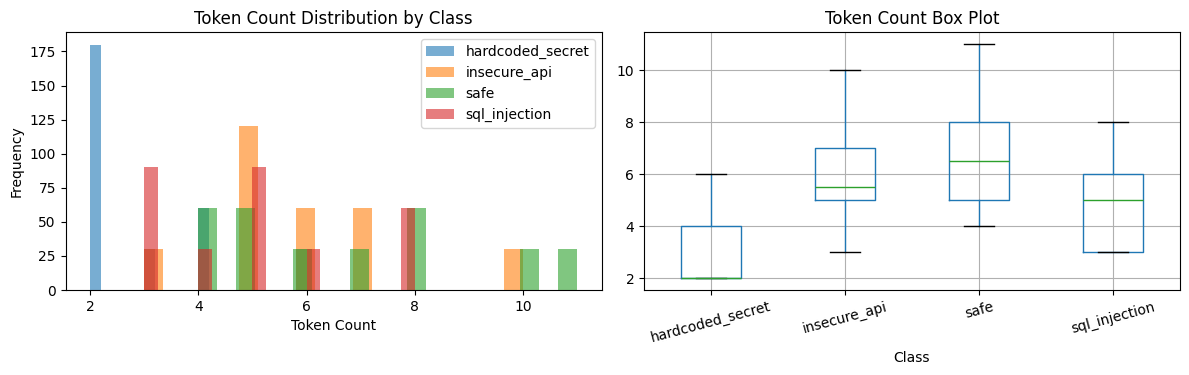


Mean token counts per class:
label
hardcoded_secret    2.9
insecure_api        5.9
safe                6.8
sql_injection       5.0
Name: token_count, dtype: float64


In [6]:
import matplotlib.pyplot as plt

df["token_count"] = df["tokens"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution by class
for label, grp in df.groupby("label"):
    axes[0].hist(grp["token_count"], alpha=0.6, bins=20, label=label)
axes[0].set_title("Token Count Distribution by Class")
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot
df.boxplot(column="token_count", by="label", ax=axes[1], rot=15)
axes[1].set_title("Token Count Box Plot")
axes[1].set_xlabel("Class")
plt.suptitle("")
plt.tight_layout()
plt.savefig("token_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nMean token counts per class:")
print(df.groupby("label")["token_count"].mean().round(1))

## 💾 6. Save Tokenized Dataset

In [7]:
df.to_csv("tokenized_dataset.csv", index=False)
print("✅ Saved → tokenized_dataset.csv")
print(f"Shape: {df.shape}")
df.head(3)

✅ Saved → tokenized_dataset.csv
Shape: (1200, 11)


,id,label,language,code_snippet,source_id,cwe,severity,description,fix_hint,tokens,token_count
0,SAFE-0279,safe,python,import secrets; token = secrets.token_hex(32),NVD-SAFE-4278,NaN,NONE,Secure coding practice: parameterised query / ...,NaN,import secrets token secrets token_hex,5
1,API-0266,insecure_api,java,new ObjectInputStream(socket.getInputStream())...,NVD-CVE-2021-3265,CWE-502,MEDIUM,"Insecure API usage: disabled TLS validation, u...","Enable TLS verification, validate inputs, avoi...",new object input stream socket get input strea...,10
2,SQL-0102,sql_injection,java,"String sql = ""SELECT * FROM orders WHERE uid='...",OWASP-BENCHMARK-011101,CWE-89,CRITICAL,Unsanitised user input concatenated directly i...,Use parameterised queries / prepared statements,string sql string_literal uid string_literal,5
